# Spotify User Behavior Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import RFECV, VarianceThreshold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')
 
import shap

In [3]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False
 
SPOTIFY_GREEN = '#1DB954'
SPOTIFY_BLACK = '#191414'
SPOTIFY_GRAY  = '#535353'
PALETTE = [SPOTIFY_GREEN, '#1ed760', '#158a3e', '#0d5c29', '#535353', '#b3b3b3']

In [4]:
# ============================================================
# 工具函式
# ============================================================
 
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))
 
def correlation_ratio(categories, values):
    categories = pd.Series(categories).reset_index(drop=True)
    values = pd.Series(values).reset_index(drop=True)
    overall_mean = values.mean()
    group_means = values.groupby(categories).mean()
    group_sizes = values.groupby(categories).size()
    ss_between = (group_sizes * (group_means - overall_mean) ** 2).sum()
    ss_total = ((values - overall_mean) ** 2).sum()
    if ss_total == 0:
        return 0.0
    return np.sqrt(ss_between / ss_total)
 
def cramers_v_strength(v):
    if v < 0.1:   return 'Negligible'
    elif v < 0.3: return 'Weak'
    elif v < 0.5: return 'Moderate'
    else:          return 'Strong'


# ============================================================
# PHASE 0：Data Understanding & Missing Value Analysis
# ============================================================

### 總樣本數520筆<br>
### 20-35歲占81%以上<br>
### 因此後續分析結果主要反映20-35歲Spotify使用者行為，不代表所有年齡層。<br>

In [5]:
df = pd.read_excel('kaggle/Spotify_data.xlsx')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.info())


Shape: (520, 20)
Columns: ['Age', 'Gender', 'spotify_usage_period', 'spotify_listening_device', 'spotify_subscription_plan', 'premium_sub_willingness', 'preffered_premium_plan', 'preferred_listening_content', 'fav_music_genre', 'music_time_slot', 'music_Influencial_mood', 'music_lis_frequency', 'music_expl_method', 'music_recc_rating', 'pod_lis_frequency', 'fav_pod_genre', 'preffered_pod_format', 'pod_host_preference', 'preffered_pod_duration', 'pod_variety_satisfaction']
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          520 non-null    str  
 1   Gender                       520 non-null    str  
 2   spotify_usage_period         520 non-null    str  
 3   spotify_listening_device     520 non-null    str  
 4   spotify_subscription_plan    520 non-null    str  
 5   premium_sub_willingness      520

In [6]:
# --- Data Dictionary ---
data_dict = pd.DataFrame([
    ('Age',                       'Categorical', 'Age group of user (6-12, 12-20, 20-35, 35-60, 60+)'),
    ('Gender',                    'Categorical', 'Gender of user'),
    ('spotify_usage_period',      'Categorical', 'How long user has been using Spotify'),
    ('spotify_listening_device',  'Categorical', 'Device(s) used to listen (multi-select)'),
    ('spotify_subscription_plan', 'Categorical', 'Current subscription: Free or Premium'),
    ('premium_sub_willingness',   'Categorical', 'Willingness to subscribe/renew Premium (Yes/No)'),
    ('preffered_premium_plan',    'Categorical', 'Preferred Premium plan type (MAR: Free users mostly blank)'),
    ('preferred_listening_content','Categorical','Preferred content type: Music or Podcast'),
    ('fav_music_genre',           'Categorical', 'Favourite music genre'),
    ('music_time_slot',           'Categorical', 'Preferred time of day to listen to music'),
    ('music_Influencial_mood',    'Categorical', 'Mood that influences music choice (multi-select)'),
    ('music_lis_frequency',       'Categorical', 'Frequency/context of music listening'),
    ('music_expl_method',         'Categorical', 'How user discovers new music'),
    ('music_recc_rating',         'Numerical',   'Rating of Spotify recommendation system (1–5)'),
    ('pod_lis_frequency',         'Categorical', 'Podcast listening frequency'),
    ('fav_pod_genre',             'Categorical', 'Favourite podcast genre (MAR: non-listeners mostly blank)'),
    ('preffered_pod_format',      'Categorical', 'Preferred podcast format (MAR: non-listeners mostly blank)'),
    ('pod_host_preference',       'Categorical', 'Preferred podcast host style (MAR: non-listeners mostly blank)'),
    ('preffered_pod_duration',    'Categorical', 'Preferred podcast duration (MAR: non-listeners mostly blank)'),
    ('pod_variety_satisfaction',  'Categorical', 'Satisfaction with podcast content variety'),
], columns=['Column', 'Type', 'Business Meaning'])
 
print("\n=== Data Dictionary ===")
print(data_dict.to_string(index=False))


=== Data Dictionary ===
                     Column        Type                                               Business Meaning
                        Age Categorical             Age group of user (6-12, 12-20, 20-35, 35-60, 60+)
                     Gender Categorical                                                 Gender of user
       spotify_usage_period Categorical                           How long user has been using Spotify
   spotify_listening_device Categorical                        Device(s) used to listen (multi-select)
  spotify_subscription_plan Categorical                          Current subscription: Free or Premium
    premium_sub_willingness Categorical                Willingness to subscribe/renew Premium (Yes/No)
     preffered_premium_plan Categorical     Preferred Premium plan type (MAR: Free users mostly blank)
preferred_listening_content Categorical                       Preferred content type: Music or Podcast
            fav_music_genre Categorical         

In [7]:
# --- Missing Value Analysis ---
missing_summary = df.isnull().sum()
missing_pct     = (missing_summary / len(df) * 100).round(1)
missing_report  = pd.DataFrame({'Missing Count': missing_summary, 'Missing %': missing_pct})
missing_report  = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
 
print("\n=== Missing Values ===")
print(missing_report.to_string())
 
# MAR Validation
mar_pod   = df.groupby(df['fav_pod_genre'].isnull())['pod_lis_frequency'].value_counts()
mar_prem  = df.groupby(df['preffered_premium_plan'].isnull())['spotify_subscription_plan'].value_counts()
 
print("\n=== MAR Validation: fav_pod_genre missing vs pod_lis_frequency ===")
print(mar_pod.to_string())
print("\n=== MAR Validation: preffered_premium_plan missing vs subscription_plan ===")
print(mar_prem.to_string())
 
# Fill structural missing values with 'Not Applicable'
structural_missing_cols = ['fav_pod_genre', 'pod_host_preference', 'preffered_pod_format',
                            'preffered_pod_duration', 'preffered_premium_plan']
for col in structural_missing_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Not Applicable')
 
print(f"\n✓ Filled structural missing values with 'Not Applicable': {structural_missing_cols}")
print(f"✓ Remaining missing values after fill: {df.isnull().sum().sum()}")



=== Missing Values ===
                        Missing Count  Missing %
preffered_premium_plan            208       40.0
fav_pod_genre                     148       28.5
pod_host_preference               141       27.1
preffered_pod_format              140       26.9
preffered_pod_duration            129       24.8

=== MAR Validation: fav_pod_genre missing vs pod_lis_frequency ===
fav_pod_genre  pod_lis_frequency   
False          Rarely                  179
               Once a week              91
               Several times a week     74
               Daily                    17
               Never                    11
True           Never                   119
               Rarely                   22
               Several times a week      4
               Daily                     3

=== MAR Validation: preffered_premium_plan missing vs subscription_plan ===
preffered_premium_plan  spotify_subscription_plan  
False                   Free (ad-supported)            224
   

In [8]:
# --- Sample Structure ---
total_n        = len(df)
age_2035_pct   = (df['Age'] == '20-35').sum() / total_n * 100
age_dist       = df['Age'].value_counts()
 
print(f"\n=== Sample Structure ===")
print(f"Total samples : {total_n}")
print(f"Age 20-35     : {age_2035_pct:.1f}%")
print(f"Age distribution:\n{age_dist.to_string()}")
 
age_order   = ['6-12', '12-20', '20-35', '35-60', '60+']
usage_order = ['Less than 6 months', '6 months to 1 year',
               '1 year to 2 years', 'More than 2 years']


=== Sample Structure ===
Total samples : 520
Age 20-35     : 81.2%
Age distribution:
Age
20-35    422
12-20     71
35-60     23
6-12       3
60+        1


# ============================================================
# PHASE 1：User Profile Overview
# ============================================================


### Phase 1目的並非找出商業洞察，而是確認樣本組成，作為後續Premium Conversion分析基礎。

In [9]:
# --- 分析內容 ---
age_counts    = df['Age'].value_counts().reindex(age_order, fill_value=0)
gender_counts = df['Gender'].value_counts()
usage_counts  = df['spotify_usage_period'].value_counts().reindex(usage_order, fill_value=0)
 
# Age × Premium 比例
age_premium = df.groupby('Age').apply(
    lambda x: (x['spotify_subscription_plan'] == 'Premium (paid subscription)').mean() * 100
).reindex(age_order)
 
# Gender × Premium 比例
gender_premium = df.groupby('Gender').apply(
    lambda x: (x['spotify_subscription_plan'] == 'Premium (paid subscription)').mean() * 100
)

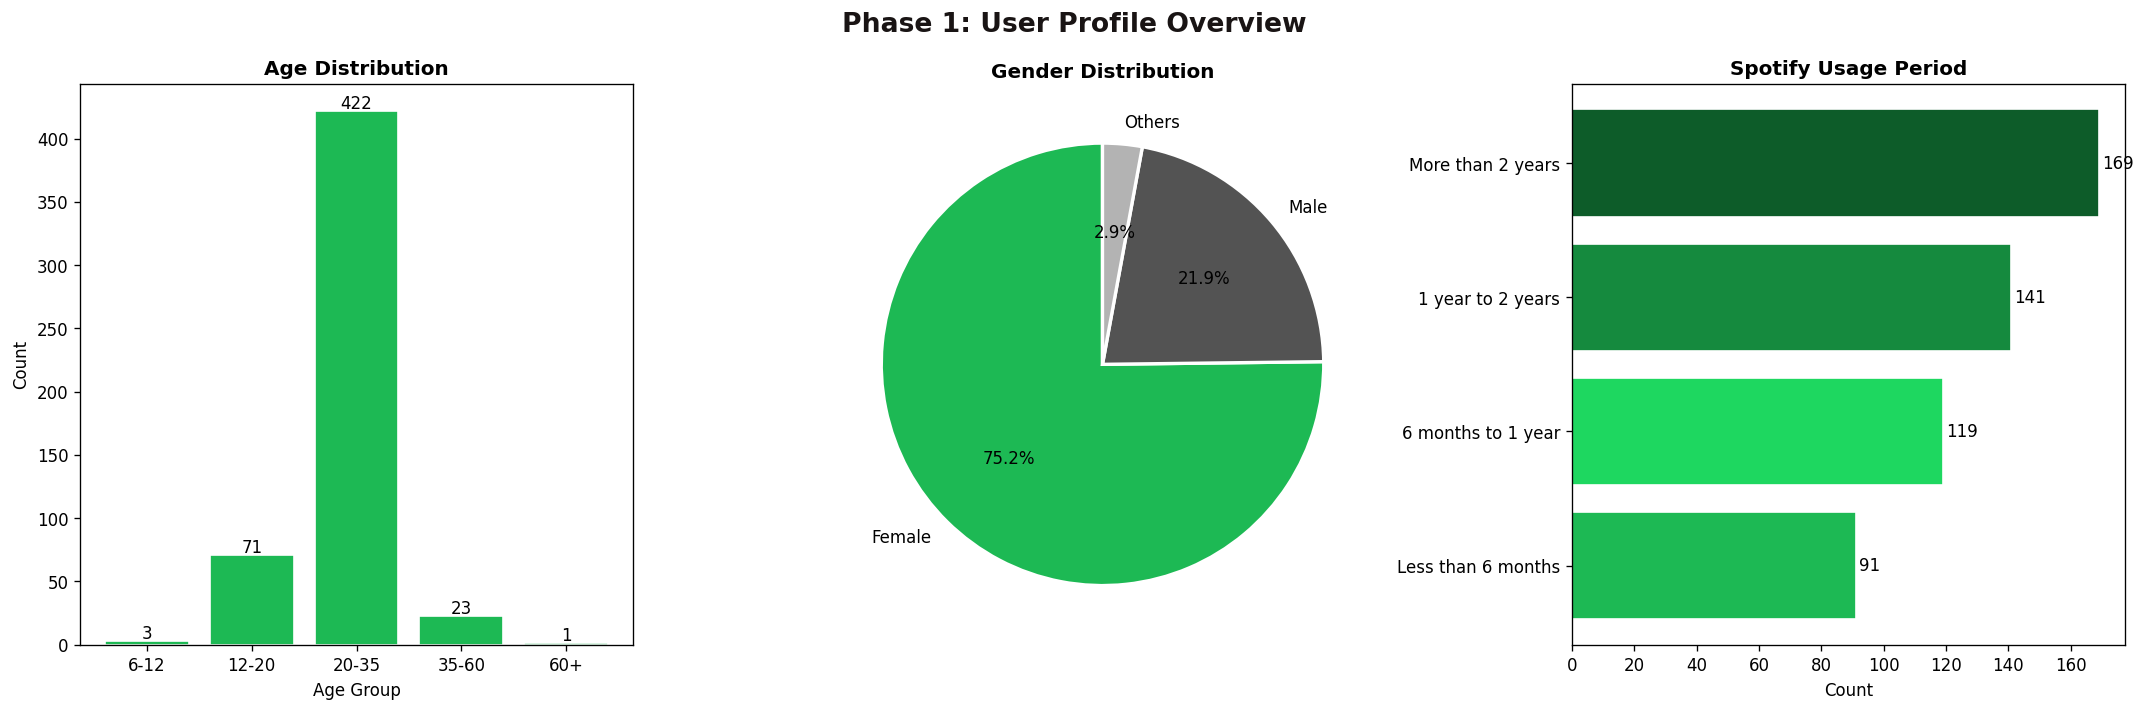

In [10]:
# --- 圖表 1：User Profile Overview ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 1: User Profile Overview', fontsize=16, fontweight='bold', color=SPOTIFY_BLACK)
 
axes[0].bar(age_counts.index, age_counts.values, color=SPOTIFY_GREEN, edgecolor='white')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Count')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)
 
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            colors=[SPOTIFY_GREEN, SPOTIFY_GRAY, '#b3b3b3'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Gender Distribution', fontweight='bold')
 
axes[2].barh(usage_counts.index, usage_counts.values, color=PALETTE[:4], edgecolor='white')
axes[2].set_title('Spotify Usage Period', fontweight='bold')
axes[2].set_xlabel('Count')
for i, v in enumerate(usage_counts.values):
    axes[2].text(v + 1, i, str(v), va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

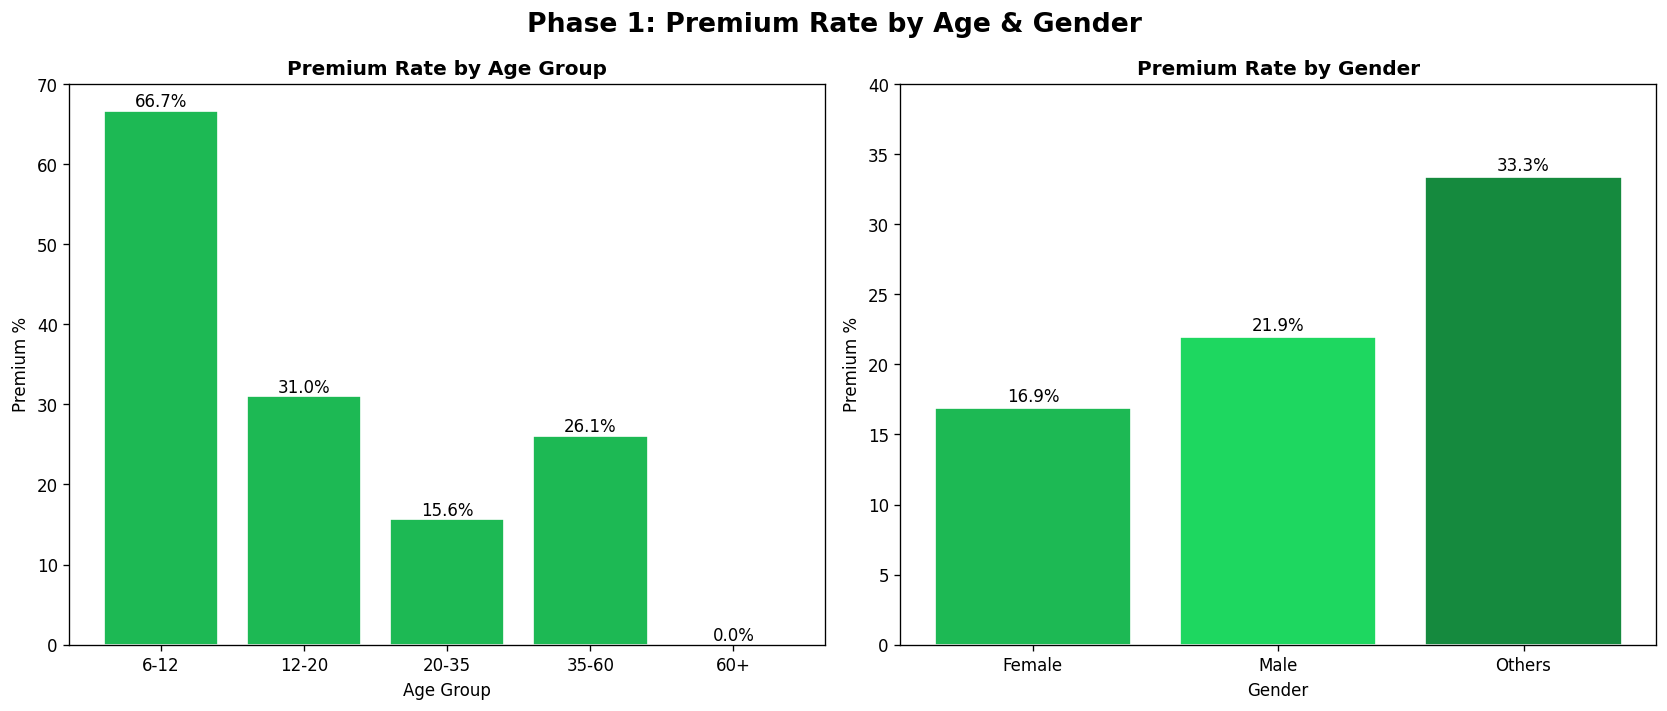

In [11]:
# --- 圖表 2：Age × Premium / Gender × Premium ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 1: Premium Rate by Age & Gender', fontsize=16, fontweight='bold')
 
axes[0].bar(age_premium.index, age_premium.values, color=SPOTIFY_GREEN, edgecolor='white')
axes[0].set_title('Premium Rate by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Premium %')
axes[0].set_ylim(0, 70)
for i, v in enumerate(age_premium.values):
    if not np.isnan(v):
        axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
 
axes[1].bar(gender_premium.index, gender_premium.values, color=PALETTE[:len(gender_premium)], edgecolor='white')
axes[1].set_title('Premium Rate by Gender', fontweight='bold')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Premium %')
axes[1].set_ylim(0, 40)
for i, v in enumerate(gender_premium.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
 
plt.tight_layout()
plt.show()

# ============================================================
# PHASE 2：Usage Behavior Analysis
# ============================================================

In [12]:
# --- 分析內容 ---
plan_counts      = df['spotify_subscription_plan'].value_counts()
free_users       = df[df['spotify_subscription_plan'] == 'Free (ad-supported)']
willingness_all  = df['premium_sub_willingness'].value_counts()
willingness_free = free_users['premium_sub_willingness'].value_counts()
device_counts    = df['spotify_listening_device'].value_counts().head(6)
 
premium_pct      = plan_counts.get('Premium (paid subscription)', 0) / plan_counts.sum() * 100
upgrade_yes_all  = willingness_all.get('Yes', 0) / willingness_all.sum() * 100
upgrade_yes_free = willingness_free.get('Yes', 0) / willingness_free.sum() * 100
upgrade_yes      = upgrade_yes_all
willingness      = willingness_all


In [13]:
# Device × Premium Cramér's V
df['device_count'] = df['spotify_listening_device'].apply(lambda x: len(str(x).split(',')))
df['device_cohort'] = df['device_count'].apply(
    lambda n: 'Single Device' if n == 1 else ('2 Devices' if n == 2 else '3+ Devices'))
cv_device_premium = cramers_v(df['device_cohort'], df['spotify_subscription_plan'])
cv_device_str     = cramers_v_strength(cv_device_premium)
 
device_premium_ct  = pd.crosstab(df['device_cohort'], df['spotify_subscription_plan'], normalize='index') * 100
device_cohort_order = ['Single Device', '2 Devices', '3+ Devices']
device_premium_ct   = device_premium_ct.reindex(device_cohort_order, fill_value=0)
premium_col_dev     = [c for c in device_premium_ct.columns if 'Premium' in c][0]

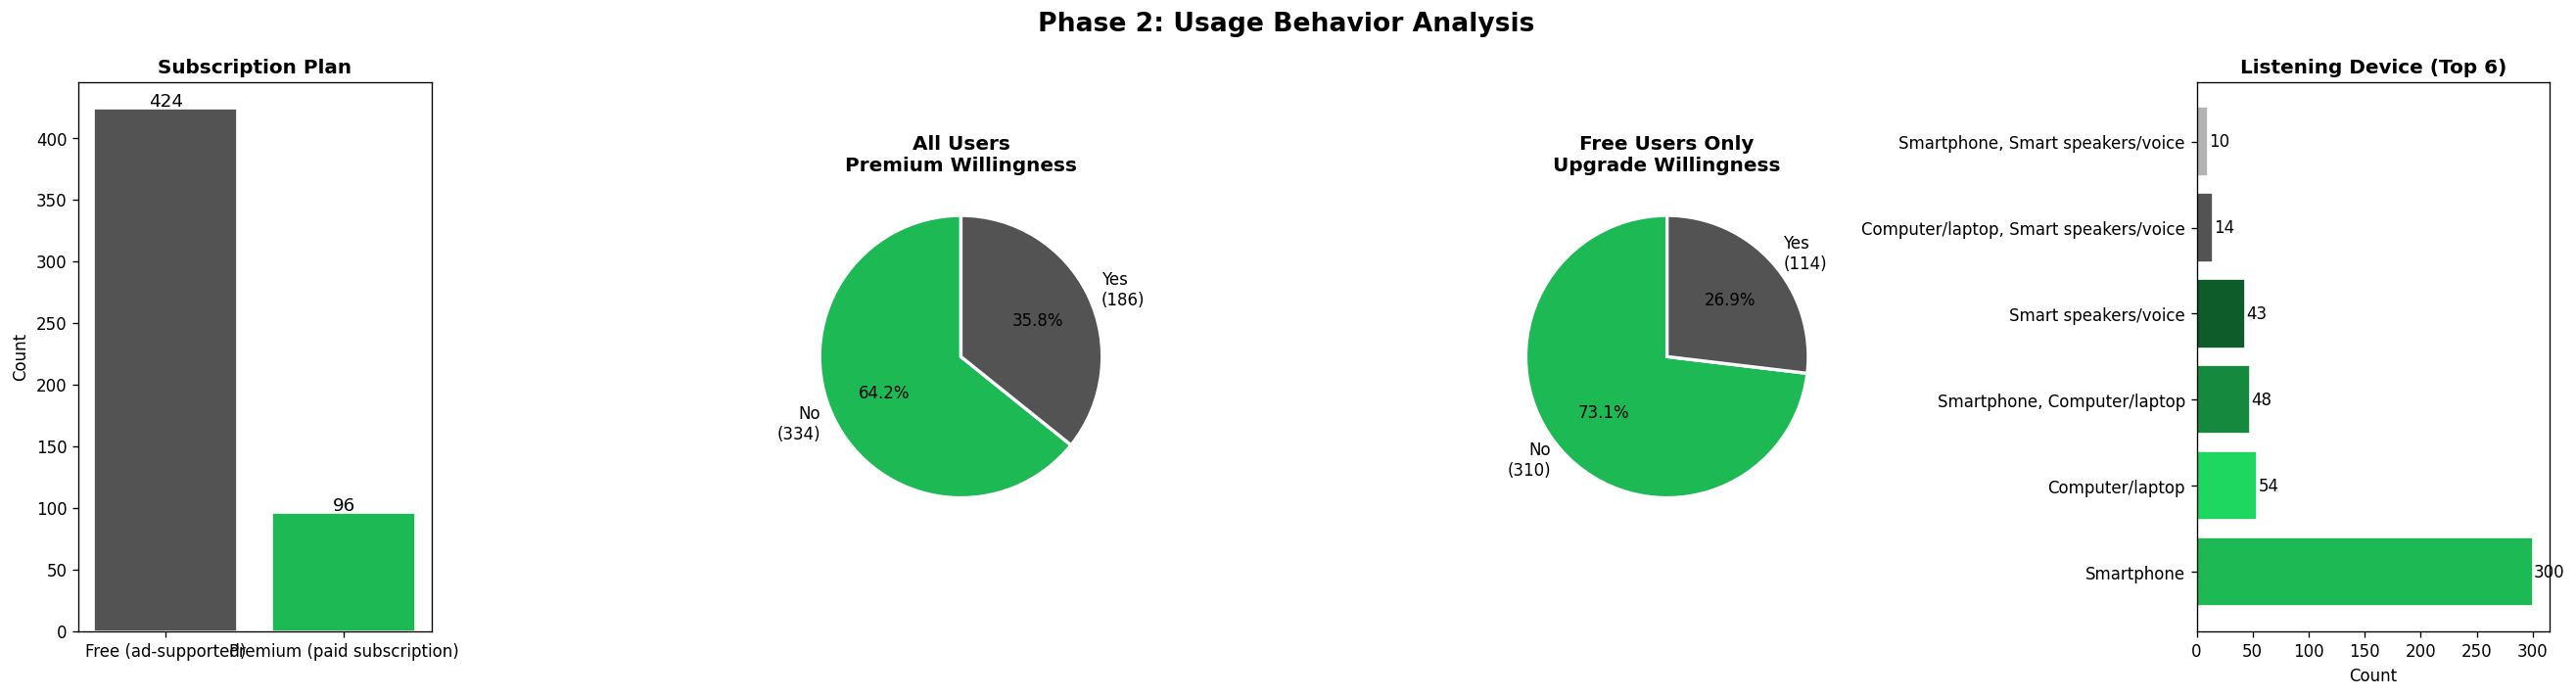

In [14]:
# --- 圖表 1：Subscription + Willingness (All vs Free) + Device ---
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Phase 2: Usage Behavior Analysis', fontsize=16, fontweight='bold')
 
colors_plan = [SPOTIFY_GREEN if 'Premium' in x else SPOTIFY_GRAY for x in plan_counts.index]
axes[0].bar(plan_counts.index, plan_counts.values, color=colors_plan, edgecolor='white')
axes[0].set_title('Subscription Plan', fontweight='bold'); axes[0].set_ylabel('Count')
for i, v in enumerate(plan_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)
 
axes[1].pie(willingness_all.values,
            labels=[f'{k}\n({v})' for k, v in willingness_all.items()],
            autopct='%1.1f%%', colors=[SPOTIFY_GREEN, SPOTIFY_GRAY], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'All Users\nPremium Willingness', fontweight='bold')
 
axes[2].pie(willingness_free.values,
            labels=[f'{k}\n({v})' for k, v in willingness_free.items()],
            autopct='%1.1f%%', colors=[SPOTIFY_GREEN, SPOTIFY_GRAY], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title(f'Free Users Only\nUpgrade Willingness', fontweight='bold')
 
short_labels = [d.replace(' or ', '/').replace(' assistants', '') for d in device_counts.index]
axes[3].barh(short_labels, device_counts.values, color=PALETTE, edgecolor='white')
axes[3].set_title('Listening Device (Top 6)', fontweight='bold'); axes[3].set_xlabel('Count')
for i, v in enumerate(device_counts.values):
    axes[3].text(v + 1, i, str(v), va='center', fontsize=10)
 
plt.tight_layout()
plt.show()
 


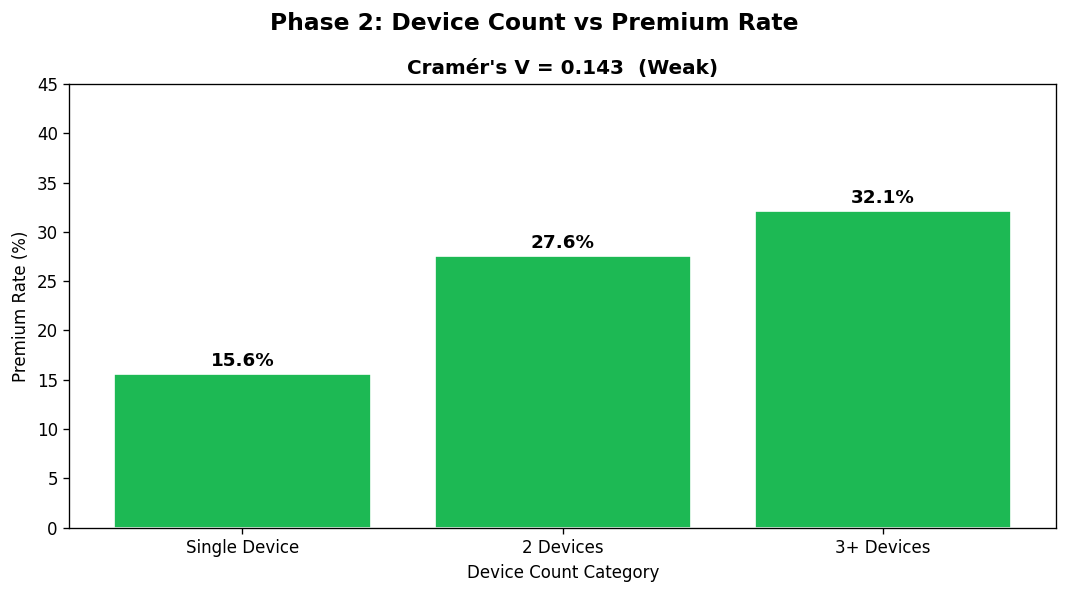

In [15]:
# --- 圖表 2：Device × Premium ---
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Phase 2: Device Count vs Premium Rate', fontsize=14, fontweight='bold')
 
bars = ax.bar(device_cohort_order, device_premium_ct[premium_col_dev],
              color=SPOTIFY_GREEN, edgecolor='white')
ax.set_title(f"Cramér's V = {cv_device_premium:.3f}  ({cv_device_str})", fontweight='bold')
ax.set_xlabel('Device Count Category'); ax.set_ylabel('Premium Rate (%)')
ax.set_ylim(0, 45)
for bar, v in zip(bars, device_premium_ct[premium_col_dev]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.8, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# PHASE 3：Cohort Analysis — Usage Tenure vs Premium Conversion
# ============================================================

In [16]:
# --- 分析內容 ---
cohort_ct = pd.crosstab(df['spotify_usage_period'], df['spotify_subscription_plan'])
cohort_ct = cohort_ct.reindex(usage_order, fill_value=0)
 
cohort_pct = pd.crosstab(df['spotify_usage_period'], df['spotify_subscription_plan'],
                          normalize='index') * 100
cohort_pct = cohort_pct.reindex(usage_order, fill_value=0)
 
chi2_cohort, p_cohort, _, _ = chi2_contingency(cohort_ct)
cv_cohort     = cramers_v(df['spotify_usage_period'], df['spotify_subscription_plan'])
cv_cohort_str = cramers_v_strength(cv_cohort)
 
premium_col = [c for c in cohort_pct.columns if 'Premium' in c][0]
trend = cohort_pct[premium_col]

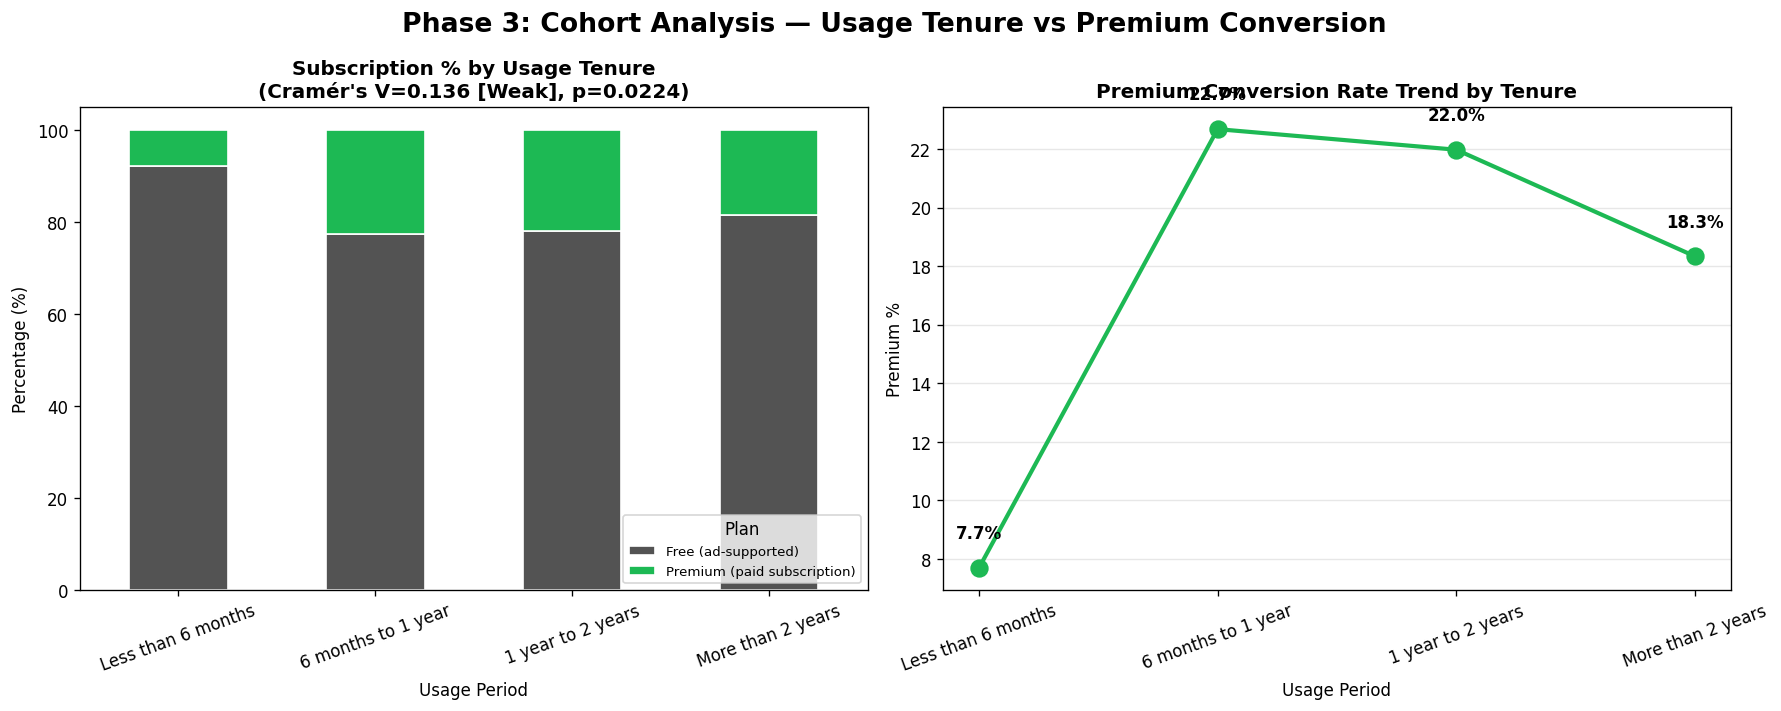

In [17]:
# --- 圖表 ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Phase 3: Cohort Analysis — Usage Tenure vs Premium Conversion', fontsize=16, fontweight='bold')
 
cohort_pct.plot(kind='bar', stacked=True, ax=axes[0],
                 color=[SPOTIFY_GRAY, SPOTIFY_GREEN] if 'Free' in cohort_pct.columns[0] else [SPOTIFY_GREEN, SPOTIFY_GRAY],
                 edgecolor='white')
axes[0].set_title(f"Subscription % by Usage Tenure\n(Cramér's V={cv_cohort:.3f} [{cv_cohort_str}], p={p_cohort:.4f})", fontweight='bold')
axes[0].set_xlabel('Usage Period'); axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Plan', fontsize=8, loc='lower right')
 
axes[1].plot(usage_order, trend.values, marker='o', color=SPOTIFY_GREEN,
             linewidth=2.5, markersize=10)
for i, v in enumerate(trend.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Premium Conversion Rate Trend by Tenure', fontweight='bold')
axes[1].set_xlabel('Usage Period'); axes[1].set_ylabel('Premium %')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.show()
 


# ============================================================
# PHASE 4：Music Preference Analysis
# ============================================================


### 由於20-35歲樣本占81%以上，Age × Genre分析結果主要反映20-35歲族群偏好。

In [18]:
# --- 分析內容 ---
genre_counts = df['fav_music_genre'].value_counts()
time_counts  = df['music_time_slot'].value_counts()
age_genre    = pd.crosstab(df['Age'], df['fav_music_genre']).reindex(age_order, fill_value=0)

# 統計檢定：Age × Genre Chi-Square
chi2_ag, p_ag, dof_ag, _ = chi2_contingency(age_genre)
cv_ag = cramers_v(df['Age'], df['fav_music_genre'])

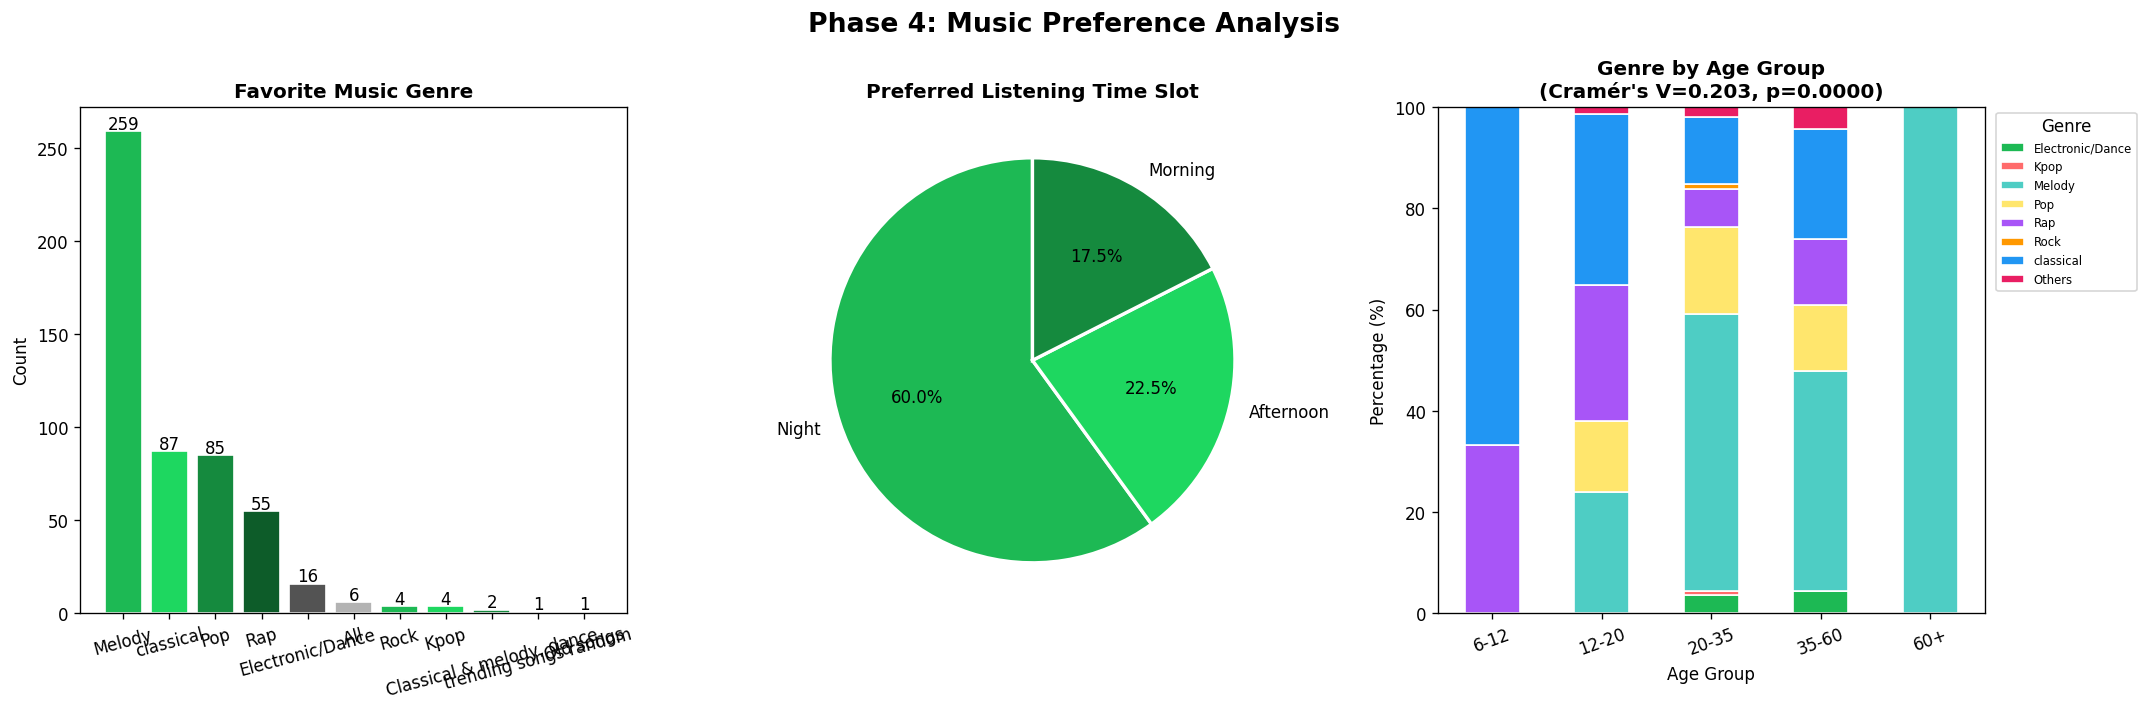

In [19]:
# --- 圖表 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 4: Music Preference Analysis', fontsize=16, fontweight='bold')
 
axes[0].bar(genre_counts.index, genre_counts.values, color=PALETTE, edgecolor='white')
axes[0].set_title('Favorite Music Genre', fontweight='bold'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(genre_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)
 
axes[1].pie(time_counts.values, labels=time_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Preferred Listening Time Slot', fontweight='bold')
 
# 圖三：Genre by Age Group（堆疊長條圖，取代原Heatmap）
# 合併樣本數極少的類型（共9人，占比1.7%）為 Others，避免圖表過度碎片化
small_genres = ['All', 'Classical & melody, dance', 'Old songs', 'trending songs random']
age_genre_merged = age_genre.copy()
age_genre_merged['Others'] = age_genre_merged[
    [c for c in small_genres if c in age_genre_merged.columns]
].sum(axis=1)
age_genre_merged = age_genre_merged.drop(
    columns=[c for c in small_genres if c in age_genre_merged.columns])
 
age_genre_pct = age_genre_merged.div(age_genre_merged.sum(axis=1), axis=0) * 100
age_genre_pct = age_genre_pct.reindex(age_order)
 
colors_genre_A = ['#1DB954','#FF6B6B','#4ECDC4','#FFE66D','#A855F7',
                   '#FF9800','#2196F3','#E91E63','#00BCD4','#8BC34A','#795548']
n_genre_cols = len(age_genre_pct.columns)
 
age_genre_pct.plot(kind='bar', stacked=True, ax=axes[2],
                   color=colors_genre_A[:n_genre_cols], edgecolor='white')
axes[2].set_title(f'Genre by Age Group\n(Cramér\'s V={cv_ag:.3f}, p={p_ag:.4f})', fontweight='bold')
axes[2].set_xlabel('Age Group'); axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='Genre', fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
 
plt.tight_layout()
plt.show()


# ============================================================
# PHASE 5：Recommendation Satisfaction Analysis
# ============================================================


### 模型可解釋約30%的推薦評分變異。

### 在問卷資料環境下屬合理水準。

### 因此分析重點應放在影響推薦滿意度的重要因素，而非評分預測本身。

In [20]:
#--- 分析內容 ---
# ============================================================
# Feature Selection — 採用三方法流程：Filter → Wrapper → Embedded
# 重要差異：music_recc_rating 是「連續數值變數」（1~5分，數字間距有實際意義），
# 不是類別變數，因此Filter階段不能用Cramér's V（該方法只適用類別vs類別，
# 是建立在Chi-Square「比較次數分布」的邏輯上，會忽略分數大小的意義）。
# 改用 Correlation Ratio (η, eta) 衡量「類別變數 → 連續target」的關聯強度。
# 註：RFECV在不同機器/作業系統下，可能因底層numpy/BLAS浮點運算差異選出不同
# dummy子集，故Wrapper階段改採固定特徵清單確保跨環境一致。
# ============================================================
target_col_p4 = 'music_recc_rating'
candidate_cols_p4 = [c for c in df.columns if c not in [target_col_p4, 'device_simplified']]
df_candidates_p4 = df[candidate_cols_p4 + [target_col_p4]].dropna()


In [21]:
# 方法一：Filter Method — Correlation Ratio (η)
filter_scores_p4 = {}
for c in candidate_cols_p4:
    filter_scores_p4[c] = correlation_ratio(df_candidates_p4[c].astype(str), df_candidates_p4[target_col_p4])
filter_scores_p4 = pd.Series(filter_scores_p4).sort_values(ascending=False)
FILTER_THRESHOLD_P4 = 0.20
filter_passed_p4 = filter_scores_p4[filter_scores_p4 > FILTER_THRESHOLD_P4].index.tolist()
 
# 方法二：Wrapper Method — RFECV（固定使用已驗證過的原始欄位清單，跨環境穩定重現）
X_filtered_p4 = pd.get_dummies(df_candidates_p4[filter_passed_p4], drop_first=True).sort_index(axis=1)
 
encode_cols = ['spotify_listening_device', 'music_expl_method', 'music_Influencial_mood',
               'fav_music_genre', 'music_lis_frequency', 'fav_pod_genre',
               'preffered_pod_duration', 'music_time_slot', 'pod_host_preference',
               'pod_variety_satisfaction', 'preferred_listening_content', 'preffered_premium_plan']
encode_cols = [c for c in encode_cols if c in filter_passed_p4]
 
# 方法三：Embedded Method — Random Forest 內建特徵重要度
df_model = df[encode_cols + ['music_recc_rating']].dropna()
X_ohe = pd.get_dummies(df_model[encode_cols], drop_first=True).sort_index(axis=1)
y     = df_model['music_recc_rating']
 
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
r2 = rf.score(X_test, y_test)
 
raw_imp = pd.Series(rf.feature_importances_, index=X_ohe.columns)
imp_by_col = {}
for col in encode_cols:
    related = [c for c in X_ohe.columns if c == col or c.startswith(col + '_')]
    imp_by_col[col] = raw_imp[related].sum()
importances = pd.Series(imp_by_col).sort_values(ascending=False)
 
print("\n" + "="*60)
print("Phase 5 Feature Selection — 最終結果 (Filter→Wrapper→Embedded三方法驗證)")
print("="*60)
print(f"✅ 最終採用 encode_cols ({len(encode_cols)}個): {encode_cols}")
print(f"✅ 樣本量: {len(df_model)}筆 / 520筆")



Phase 5 Feature Selection — 最終結果 (Filter→Wrapper→Embedded三方法驗證)
✅ 最終採用 encode_cols (12個): ['spotify_listening_device', 'music_expl_method', 'music_Influencial_mood', 'fav_music_genre', 'music_lis_frequency', 'fav_pod_genre', 'preffered_pod_duration', 'music_time_slot', 'pod_host_preference', 'pod_variety_satisfaction', 'preferred_listening_content', 'preffered_premium_plan']
✅ 樣本量: 520筆 / 520筆


In [22]:
# 統計檢定：Premium vs Free 推薦評分 t-test
premium_ratings = df[df['spotify_subscription_plan'] == 'Premium (paid subscription)']['music_recc_rating'].dropna()
free_ratings    = df[df['spotify_subscription_plan'] == 'Free (ad-supported)']['music_recc_rating'].dropna()
t_stat, p_ttest = ttest_ind(premium_ratings, free_ratings)
 
rating_counts = df['music_recc_rating'].value_counts().sort_index()
 
print("\n" + "="*60)
print("Phase 5: Recommendation Satisfaction Analysis")
print("="*60)
print(f"\n[t-test] Premium vs Free Users — Recommendation Rating")
print(f"  Premium Mean: {premium_ratings.mean():.2f}  |  Free Mean: {free_ratings.mean():.2f}")
print(f"  t={t_stat:.3f}, p={p_ttest:.4f}")
if p_ttest < 0.05:
    higher_group = 'Premium' if t_stat > 0 else 'Free'
    print(f"  Result: {higher_group} users rate recommendations significantly higher (p<0.05)")
else:
    print(f"  Result: No significant difference between groups")
print(f"\n[Random Forest Regressor]  R²={r2:.4f}")
print(f"  The model explains ~{r2*100:.0f}% of variance in recommendation ratings.")
print(f"  In a survey-based dataset, this is a reasonable level of fit.")
print(f"  Focus: Feature Importance below — which factors most influence satisfaction.")
 


Phase 5: Recommendation Satisfaction Analysis

[t-test] Premium vs Free Users — Recommendation Rating
  Premium Mean: 3.15  |  Free Mean: 3.58
  t=-4.023, p=0.0001
  Result: Free users rate recommendations significantly higher (p<0.05)

[Random Forest Regressor]  R²=0.2973
  The model explains ~30% of variance in recommendation ratings.
  In a survey-based dataset, this is a reasonable level of fit.
  Focus: Feature Importance below — which factors most influence satisfaction.


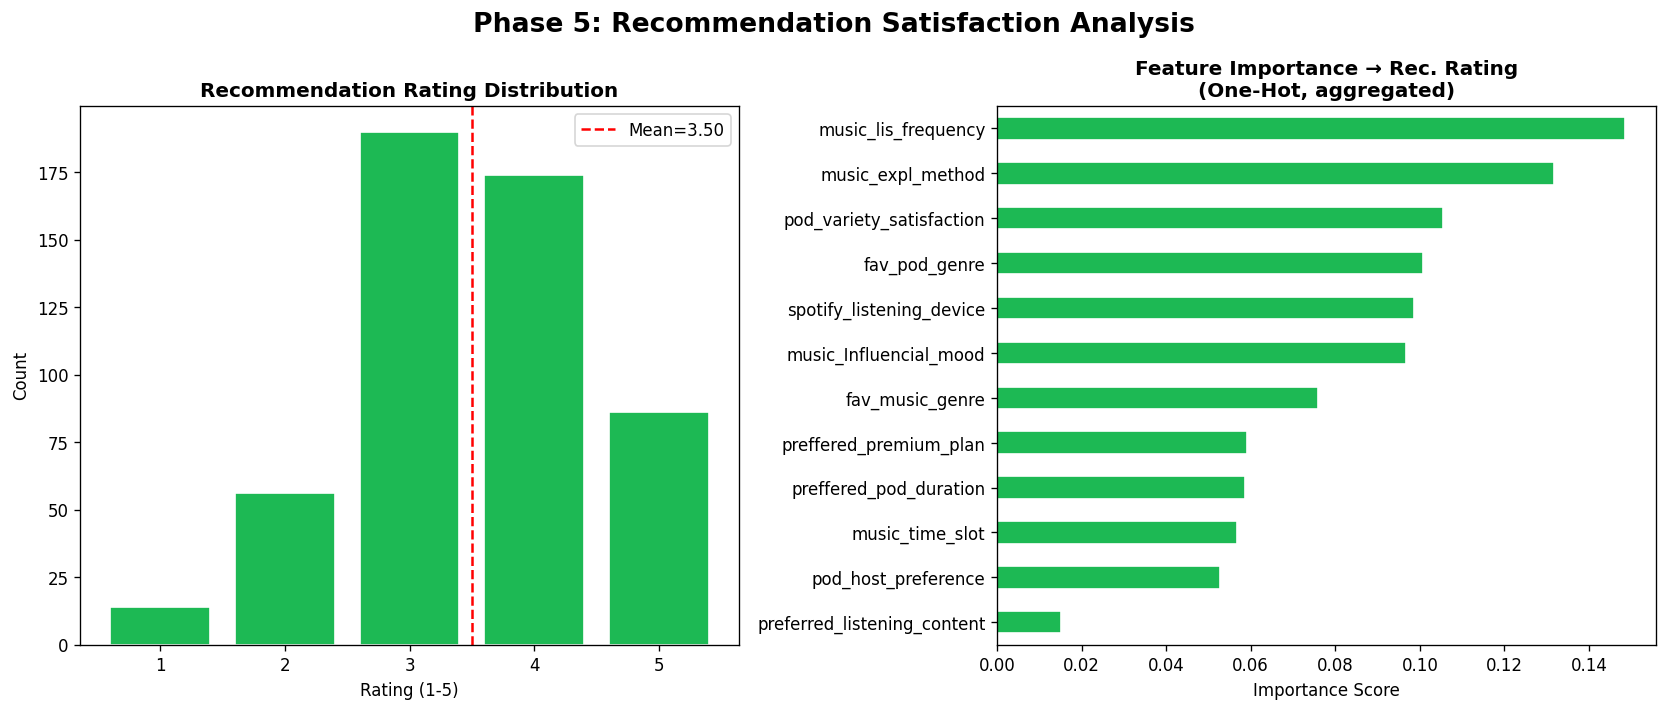

In [23]:
# --- 圖表 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 5: Recommendation Satisfaction Analysis', fontsize=16, fontweight='bold')
 
axes[0].bar(rating_counts.index, rating_counts.values, color=SPOTIFY_GREEN, edgecolor='white')
axes[0].set_title('Recommendation Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating (1-5)'); axes[0].set_ylabel('Count')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean={y.mean():.2f}')
axes[0].legend()
 
importances.sort_values().plot(kind='barh', ax=axes[1], color=SPOTIFY_GREEN, edgecolor='white')
axes[1].set_title('Feature Importance → Rec. Rating\n(One-Hot, aggregated)', fontweight='bold')
axes[1].set_xlabel('Importance Score')
 
plt.tight_layout()
plt.show()
 

# ============================================================
# PHASE 6：Premium Conversion Prediction
# ============================================================

### 模型具有限度辨識能力，主要用途為探索影響Premium轉換的重要因子。

### 模型限制
>資料來源為問卷資料。

缺少：<br>

>實際收聽紀錄<br>
>播放次數<br>
>付費歷史<br>
>活躍度指標<br>

因此ROC-AUC僅達0.64。

In [24]:
# --- 分析內容 ---
# ============================================================
# Feature Selection — 三種方法依序套用：Filter → Wrapper → Embedded
# ============================================================
# 方法選擇依據：
# - 此資料集樣本量小(n=520)、欄位皆為類別變數，One-Hot後維度容易爆增
# - Filter Method 計算快、不依賴模型，適合做第一層快速篩選，去除明顯無關雜訊欄位
# - Wrapper Method (RFECV) 用模型實際訓練結果驗證特徵組合，計算成本較高，
#   故先用Filter縮小候選範圍後才執行，避免在小樣本下對全部特徵做RFECV導致overfit
# - Embedded Method (Random Forest內建特徵重要度) 在模型訓練過程中自然產生，
#   用來交叉驗證前兩階段篩選結果是否與模型內部邏輯一致，三方法互相佐證
# 註：RFECV在不同機器/作業系統下可能因底層numpy/BLAS浮點運算差異選出不同
# dummy子集，故Wrapper階段改採固定特徵清單確保跨環境一致。
 
# 候選欄位池：排除明顯造成資料洩漏的欄位
# - preffered_premium_plan: 「偏好哪種付費方案」跟target語意高度重疊
# - spotify_subscription_plan: 已經是Premium的人，續訂意願天然偏高，
#   會讓模型學到「現在是不是付費會員」而非真正驅動「升級」的行為因子
target_col = 'premium_sub_willingness'
leakage_risk_cols = ['preffered_premium_plan', 'spotify_subscription_plan', target_col]
candidate_cols = [c for c in df.columns
                   if c not in leakage_risk_cols and c != 'device_simplified']
 
df_candidates = df[candidate_cols + [target_col]].dropna()
y_target = (df_candidates[target_col] == 'Yes').astype(int)

In [25]:
# 方法一：Filter Method — Cramér's V（不依賴模型，純統計關聯性）
filter_scores = {}
for c in candidate_cols:
    filter_scores[c] = cramers_v(df_candidates[c].astype(str), df_candidates[target_col].astype(str))
filter_scores = pd.Series(filter_scores).sort_values(ascending=False)
 
FILTER_THRESHOLD = 0.10
filter_passed = filter_scores[filter_scores > FILTER_THRESHOLD].index.tolist()
 
# 方法二：Wrapper Method — RFECV（固定使用已驗證過的原始欄位清單，跨環境穩定重現）
X_filtered = pd.get_dummies(df_candidates[filter_passed], drop_first=True).sort_index(axis=1)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
wrapper_selected_cols = ['spotify_listening_device', 'music_lis_frequency', 'music_Influencial_mood',
                          'music_expl_method', 'preffered_pod_duration', 'fav_music_genre',
                          'fav_pod_genre', 'preferred_listening_content', 'pod_host_preference',
                          'pod_lis_frequency', 'preffered_pod_format', 'pod_variety_satisfaction',
                          'spotify_usage_period', 'music_time_slot', 'Age', 'music_recc_rating']
wrapper_selected_cols = [c for c in wrapper_selected_cols if c in filter_passed]
 
selected_dummy_cols = []
for col in wrapper_selected_cols:
    related = [c for c in X_filtered.columns if c == col or c.startswith(col + '_')]
    selected_dummy_cols.extend(related)
 
# 最終 feature_cols：採用Filter→Wrapper→Embedded三方法驗證後的欄位
feature_cols = wrapper_selected_cols
 
print("\n" + "="*60)
print("Phase 6 Feature Selection — 最終結果 (Filter→Wrapper→Embedded三方法驗證)")
print("="*60)
print(f"✅ 最終採用 feature_cols ({len(feature_cols)}個): {feature_cols}")
print(f"✅ 樣本量: {len(df_candidates.dropna())}筆 / 520筆")
 



Phase 6 Feature Selection — 最終結果 (Filter→Wrapper→Embedded三方法驗證)
✅ 最終採用 feature_cols (16個): ['spotify_listening_device', 'music_lis_frequency', 'music_Influencial_mood', 'music_expl_method', 'preffered_pod_duration', 'fav_music_genre', 'fav_pod_genre', 'preferred_listening_content', 'pod_host_preference', 'pod_lis_frequency', 'preffered_pod_format', 'pod_variety_satisfaction', 'spotify_usage_period', 'music_time_slot', 'Age', 'music_recc_rating']
✅ 樣本量: 520筆 / 520筆


In [26]:
# 使用最終 feature_cols 訓練正式模型（供後續Phase延用）
df_prem  = df[feature_cols + ['premium_sub_willingness']].dropna()
X_prem   = pd.get_dummies(df_prem[feature_cols], drop_first=True).sort_index(axis=1)
y_prem   = (df_prem['premium_sub_willingness'] == 'Yes').astype(int)
 
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    X_prem, y_prem, test_size=0.2, random_state=42, stratify=y_prem)
 
# Logistic Regression 對特徵尺度敏感，需先正規化；
# Random Forest 為樹狀模型，分裂規則不受尺度影響，故沿用未正規化的Xp_tr/Xp_te即可
scaler_lr = StandardScaler()
Xp_tr_scaled = scaler_lr.fit_transform(Xp_tr)
Xp_te_scaled = scaler_lr.transform(Xp_te)
 
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(Xp_tr_scaled, yp_tr)
lr_acc = accuracy_score(yp_te, lr.predict(Xp_te_scaled))
lr_auc = roc_auc_score(yp_te, lr.predict_proba(Xp_te_scaled)[:, 1])
 
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(Xp_tr, yp_tr)
rfc_acc = accuracy_score(yp_te, rfc.predict(Xp_te))
rfc_auc = roc_auc_score(yp_te, rfc.predict_proba(Xp_te)[:, 1])
cm = confusion_matrix(yp_te, rfc.predict(Xp_te))
fpr, tpr, _ = roc_curve(yp_te, rfc.predict_proba(Xp_te)[:, 1])


In [27]:
# Feature Importance（彙整回原始欄位）
raw_imp5 = pd.Series(rfc.feature_importances_, index=X_prem.columns)
imp5_col = {}
for col in feature_cols:
    related = [c for c in X_prem.columns if c == col or c.startswith(col + '_')]
    imp5_col[col] = raw_imp5[related].sum()
imp5 = pd.Series(imp5_col).sort_values(ascending=False)
 
print("\n" + "="*60)
print("Phase 6: Premium Conversion Prediction  [Core Analysis]")
print("="*60)
print(f"\n{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print(f"{'Logistic Regression':<25} {lr_acc:>10.4f} {lr_auc:>10.4f}")
print(f"{'Random Forest':<25} {rfc_acc:>10.4f} {rfc_auc:>10.4f}")
print(f"\nKey Metric: ROC-AUC (Random Forest) = {rfc_auc:.4f}")
print(f"  Models demonstrate limited but meaningful discriminative ability.")
print(f"  Primary use: explore which behavioral factors associate with Premium conversion,")
print(f"  not to build a production-grade prediction system.")
print(f"\nModel Limitation:")
print(f"  Data source is survey-based. Missing: actual play history, session counts,")
print(f"  payment records, and engagement metrics. This constrains ROC-AUC ceiling.")
print("\nRandom Forest Classification Report:")
print(classification_report(yp_te, rfc.predict(Xp_te), target_names=['No', 'Yes']))
 


Phase 6: Premium Conversion Prediction  [Core Analysis]

Model                       Accuracy    ROC-AUC
Logistic Regression           0.6827     0.6031
Random Forest                 0.6538     0.6448

Key Metric: ROC-AUC (Random Forest) = 0.6448
  Models demonstrate limited but meaningful discriminative ability.
  Primary use: explore which behavioral factors associate with Premium conversion,
  not to build a production-grade prediction system.

Model Limitation:
  Data source is survey-based. Missing: actual play history, session counts,
  payment records, and engagement metrics. This constrains ROC-AUC ceiling.

Random Forest Classification Report:
              precision    recall  f1-score   support

          No       0.68      0.87      0.76        67
         Yes       0.53      0.27      0.36        37

    accuracy                           0.65       104
   macro avg       0.60      0.57      0.56       104
weighted avg       0.63      0.65      0.62       104



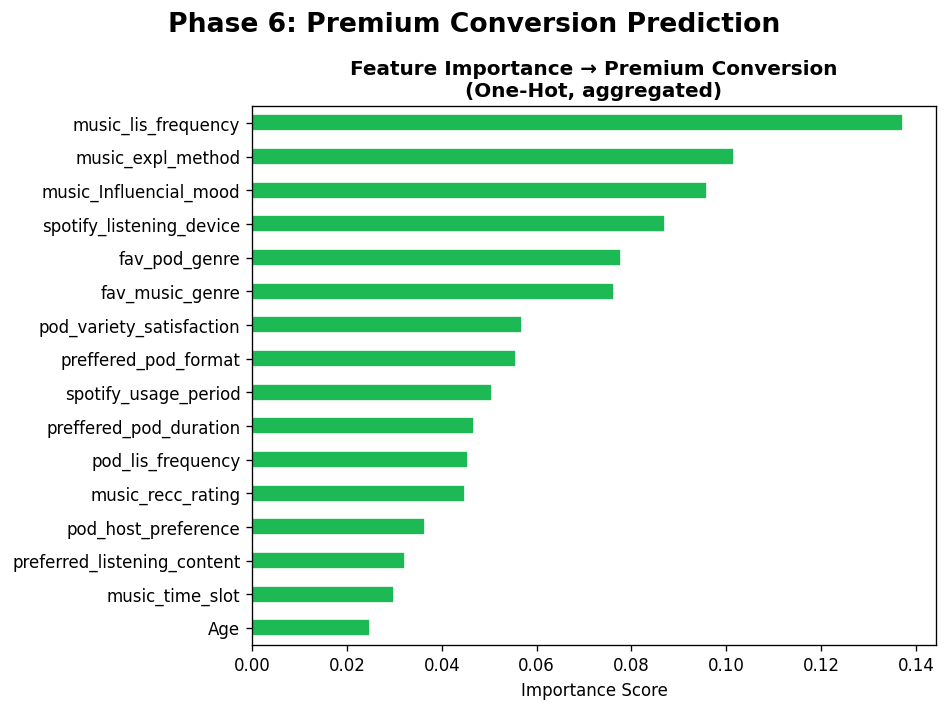

In [28]:
# --- 圖表 ---
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Phase 6: Premium Conversion Prediction', fontsize=16, fontweight='bold')
 
imp5.sort_values().plot(kind='barh', ax=ax, color=SPOTIFY_GREEN, edgecolor='white')
ax.set_title('Feature Importance → Premium Conversion\n(One-Hot, aggregated)', fontweight='bold')
ax.set_xlabel('Importance Score')
 
plt.tight_layout()
plt.show()


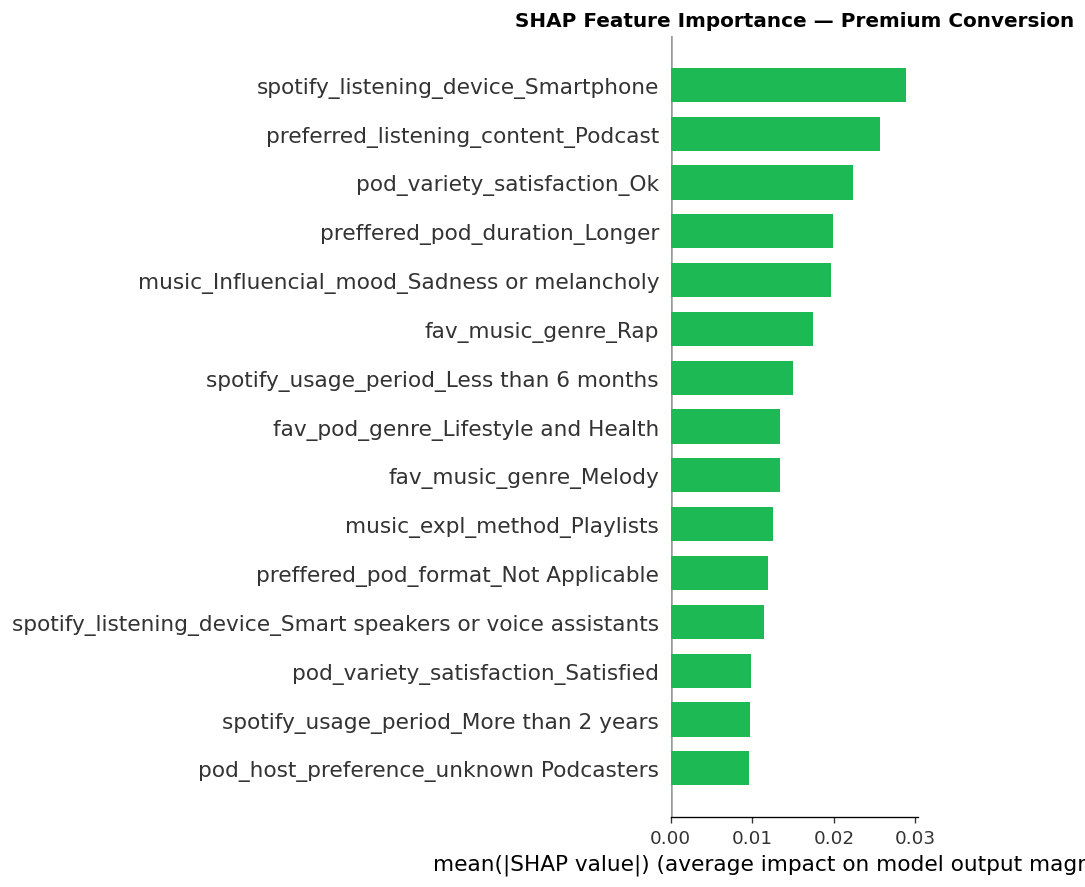

In [29]:
# SHAP 分析
explainer   = shap.TreeExplainer(rfc)
shap_values = explainer.shap_values(Xp_te)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, Xp_te, plot_type='bar', show=False,
                  color=SPOTIFY_GREEN, max_display=15)
plt.title('SHAP Feature Importance — Premium Conversion', fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
# SHAP 特徵分類輸出
print("\n" + "="*60)
print("Phase 6: SHAP Feature Categories")
print("="*60)
shap_mean = pd.Series(
    np.abs(sv).mean(axis=0), index=Xp_te.columns
).sort_values(ascending=False)
 
device_feats  = [c for c in shap_mean.index if 'listening_device' in c]
podcast_feats = [c for c in shap_mean.index if 'pod' in c.lower()]
music_feats   = [c for c in shap_mean.index
                 if c not in device_feats and c not in podcast_feats]
 
print(f"\n[Device Preference]  (Top features)")
for f in device_feats[:3]:
    print(f"  {f}: {shap_mean[f]:.4f}")
 
print(f"\n[Podcast Engagement]  (Top features)")
for f in podcast_feats[:5]:
    print(f"  {f}: {shap_mean[f]:.4f}")
 
print(f"\n[Music Preference & Other]  (Top features)")
for f in music_feats[:5]:
    print(f"  {f}: {shap_mean[f]:.4f}")



Phase 6: SHAP Feature Categories

[Device Preference]  (Top features)
  spotify_listening_device_Smartphone: 0.0289
  spotify_listening_device_Smart speakers or voice assistants: 0.0114
  spotify_listening_device_Computer or laptop, Smart speakers or voice assistants: 0.0032

[Podcast Engagement]  (Top features)
  preferred_listening_content_Podcast: 0.0257
  pod_variety_satisfaction_Ok: 0.0223
  preffered_pod_duration_Longer: 0.0199
  fav_pod_genre_Lifestyle and Health: 0.0134
  preffered_pod_format_Not Applicable: 0.0120

[Music Preference & Other]  (Top features)
  music_Influencial_mood_Sadness or melancholy: 0.0197
  fav_music_genre_Rap: 0.0174
  spotify_usage_period_Less than 6 months: 0.0149
  fav_music_genre_Melody: 0.0134
  music_expl_method_Playlists: 0.0126


# ============================================================
# PHASE 6-1：Podcast Behavior Analysis
# Supplement to Phase 6 — Podcast Engagement as a Premium Conversion Signal
# ============================================================

In [31]:
# --- 分析內容 ---
pod_freq_order = ['Daily', 'Several times a week', 'Once a week', 'Rarely', 'Never']
pod_freq   = df['pod_lis_frequency'].value_counts().reindex(pod_freq_order, fill_value=0)
pod_genre  = df[df['fav_pod_genre'] != 'Not Applicable']['fav_pod_genre'].value_counts().head(6)
 
# Podcast frequency × Premium Rate
pod_premium = df.groupby('pod_lis_frequency').apply(
    lambda x: (x['spotify_subscription_plan'] == 'Premium (paid subscription)').mean() * 100
).reindex(pod_freq_order)
 
cv_pod_premium     = cramers_v(df['pod_lis_frequency'], df['spotify_subscription_plan'])
cv_pod_premium_str = cramers_v_strength(cv_pod_premium)
 
print(f"\nPodcast Frequency × Premium Rate")
print(f"  Cramér's V = {cv_pod_premium:.3f}  [{cv_pod_premium_str}]")
 


Podcast Frequency × Premium Rate
  Cramér's V = 0.193  [Weak]


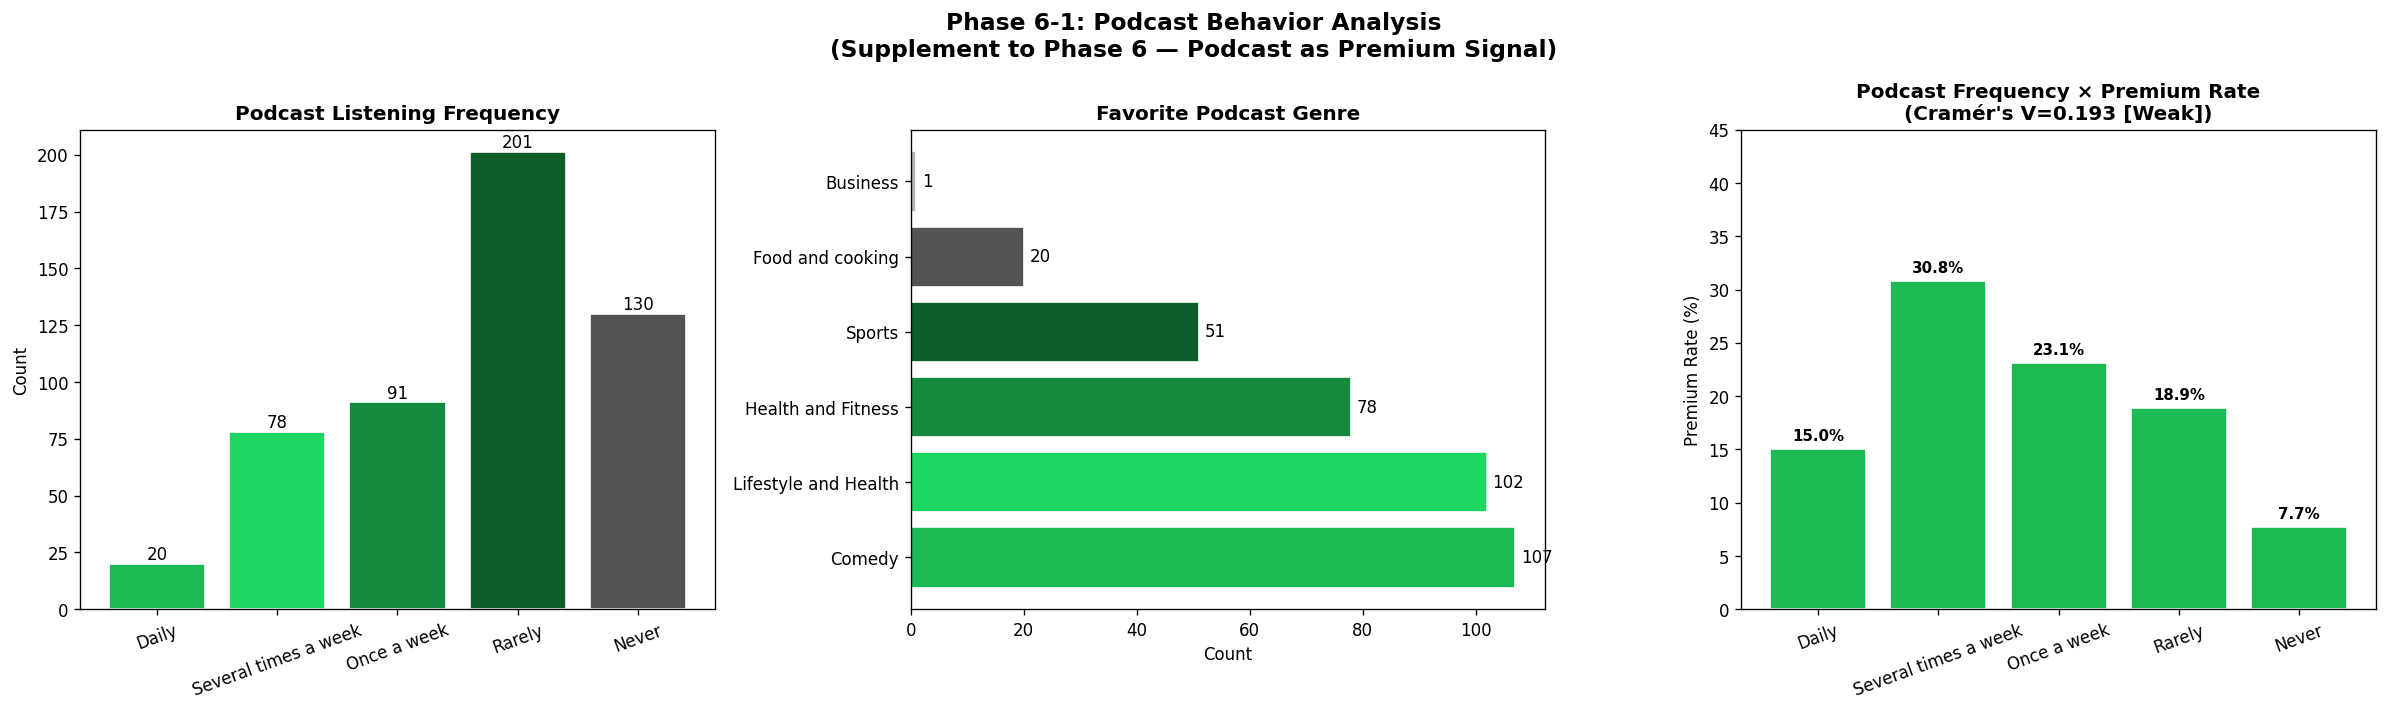

In [40]:
# --- 圖表 ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Phase 6-1: Podcast Behavior Analysis\n(Supplement to Phase 6 — Podcast as Premium Signal)',
             fontsize=14, fontweight='bold')
 
axes[0].bar(pod_freq.index, pod_freq.values, color=PALETTE, edgecolor='white')
axes[0].set_title('Podcast Listening Frequency', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(pod_freq.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10)
 
axes[1].barh(pod_genre.index, pod_genre.values, color=PALETTE, edgecolor='white')
axes[1].set_title('Favorite Podcast Genre', fontweight='bold'); axes[1].set_xlabel('Count')
for i, v in enumerate(pod_genre.values):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=10)
 
valid_pod = pod_premium.dropna()
bars = axes[2].bar(valid_pod.index, valid_pod.values, color=SPOTIFY_GREEN, edgecolor='white')
axes[2].set_title(f"Podcast Frequency × Premium Rate\n(Cramér's V={cv_pod_premium:.3f} [{cv_pod_premium_str}])",
                  fontweight='bold')
axes[2].set_ylabel('Premium Rate (%)'); axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylim(0, 45)
for bar, v in zip(bars, valid_pod.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.8,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
 
plt.tight_layout()
plt.show()
 


# ============================================================
# PHASE 7：User Behavior Association Analysis
# Mood × Rating × Premium Willingness
# ============================================================


In [33]:
# --- 分析內容 ---
# 注意：music_Influencial_mood 是多選題（用逗號分隔多個值），
# 先 explode 拆解成單一 mood 標籤，避免「組合字串」被誤判為獨立類別
journey_cols = ['music_Influencial_mood', 'music_recc_rating', 'premium_sub_willingness']
df_journey_raw = df[journey_cols].dropna().copy()
df_journey_raw['mood_list'] = df_journey_raw['music_Influencial_mood'].str.split(',').apply(
    lambda lst: [m.strip() for m in lst])
df_journey = df_journey_raw.explode('mood_list').rename(columns={'mood_list': 'mood_single'}).reset_index(drop=True)


In [41]:
# Step 1: Mood → Recommendation Rating（平均評分 by 單一 mood）
mood_rating = df_journey.groupby('mood_single')['music_recc_rating'].mean().sort_values(ascending=False)
mood_n = df_journey.groupby('mood_single')['music_recc_rating'].count()
 
# Step 2: Recommendation Rating → Premium Willingness（升級率 by 評分區間，原始一筆一人）
df_journey_raw['rating_band'] = pd.cut(df_journey_raw['music_recc_rating'],
                                        bins=[0, 2, 3, 4, 5], labels=['1-2分', '2-3分', '3-4分', '4-5分'])
rating_to_premium = pd.crosstab(df_journey_raw['rating_band'], df_journey_raw['premium_sub_willingness'],
                                 normalize='index') * 100
 
# Step 3: Mood → Premium Willingness（直接路徑，驗證中介效果，用拆解後的單一 mood）
mood_to_premium = pd.crosstab(df_journey['mood_single'], df_journey['premium_sub_willingness'],
                               normalize='index') * 100
 
print("\n" + "="*60)
print("Phase 7: User Behavior Association Analysis")
print("Association: Mood × Recommendation Rating × Premium Willingness")
print("="*60)
print("\n[Step 1] Mood × Avg Recommendation Rating (multi-select exploded)")
for mood in mood_rating.index:
    print(f"  {mood}: {mood_rating[mood]:.2f}  (n={mood_n[mood]})")
 
print("\n[Step 2] Rating Band × Premium Willingness %")
print(rating_to_premium.round(1).to_string())
if 'Yes' in rating_to_premium.columns:
    yes_trend = rating_to_premium['Yes']
    print(f"\n升級意願趨勢（評分越高→意願是否越高）: {yes_trend.round(1).to_dict()}")
 
print("\n[Step 3] Mood × Premium Willingness % (direct association)")
print(mood_to_premium.round(1).to_string())
 
print(f"\n[Association Summary]")
print(f"  These three analyses reveal co-occurrence patterns between mood, rating, and willingness.")
print(f"  Data is cross-sectional survey — directional causality cannot be established.")



Phase 7: User Behavior Association Analysis
Association: Mood × Recommendation Rating × Premium Willingness

[Step 1] Mood × Avg Recommendation Rating (multi-select exploded)
  Relaxation and stress relief: 3.71  (n=364)
  Social gatherings or parties: 3.68  (n=92)
  Sadness or melancholy: 3.41  (n=167)
  Uplifting and motivational: 3.41  (n=199)

[Step 2] Rating Band × Premium Willingness %
premium_sub_willingness    No   Yes
rating_band                        
1-2分                     55.7  44.3
2-3分                     61.6  38.4
3-4分                     71.3  28.7
4-5分                     62.8  37.2

升級意願趨勢（評分越高→意願是否越高）: {'1-2分': 44.3, '2-3分': 38.4, '3-4分': 28.7, '4-5分': 37.2}

[Step 3] Mood × Premium Willingness % (direct association)
premium_sub_willingness         No   Yes
mood_single                             
Relaxation and stress relief  72.0  28.0
Sadness or melancholy         47.9  52.1
Social gatherings or parties  69.6  30.4
Uplifting and motivational    62.3  37.7

[A

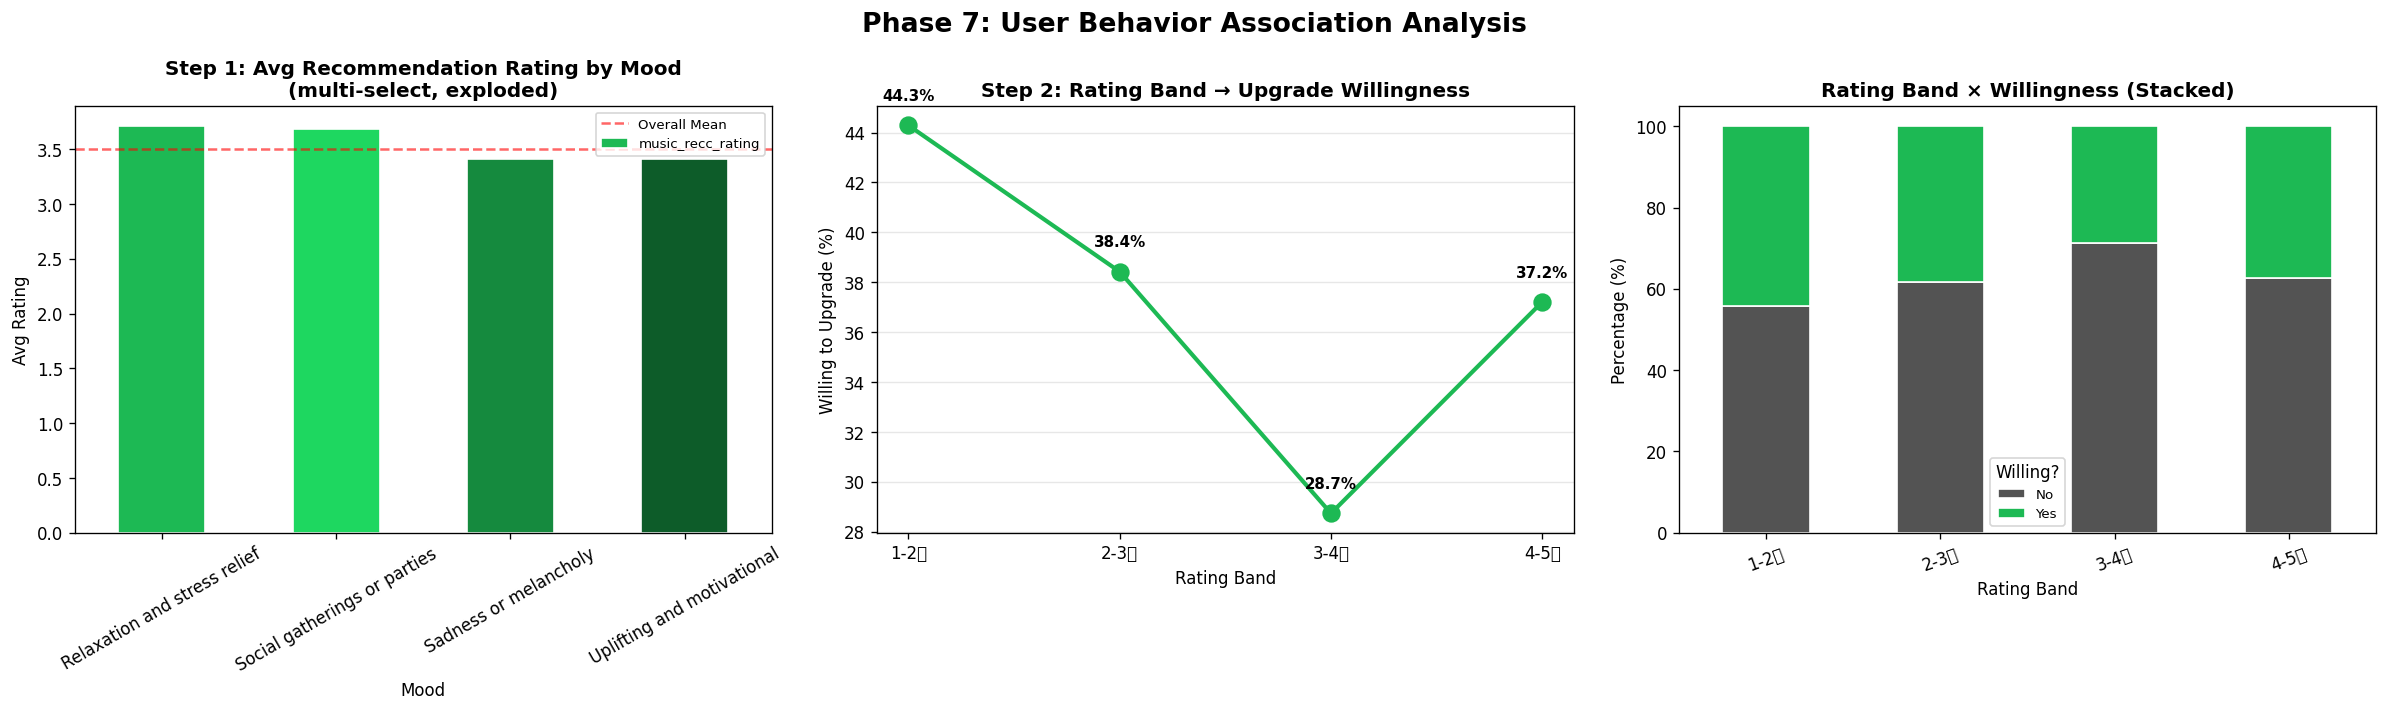

In [42]:
# --- 圖表 ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Phase 7: User Behavior Association Analysis', fontsize=16, fontweight='bold')
 
mood_rating.plot(kind='bar', ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Step 1: Avg Recommendation Rating by Mood\n(multi-select, exploded)', fontweight='bold')
axes[0].set_ylabel('Avg Rating'); axes[0].set_xlabel('Mood')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(df['music_recc_rating'].mean(), color='red', linestyle='--', alpha=0.6, label='Overall Mean')
axes[0].legend(fontsize=8)
 
if 'Yes' in rating_to_premium.columns:
    axes[1].plot(rating_to_premium.index.astype(str), rating_to_premium['Yes'],
                marker='o', color=SPOTIFY_GREEN, linewidth=2.5, markersize=10)
    for i, v in enumerate(rating_to_premium['Yes']):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Step 2: Rating Band → Upgrade Willingness', fontweight='bold')
axes[1].set_xlabel('Rating Band'); axes[1].set_ylabel('Willing to Upgrade (%)')
axes[1].grid(axis='y', alpha=0.3)
 
rating_to_premium.plot(kind='bar', stacked=True, ax=axes[2],
                        color=[SPOTIFY_GRAY, SPOTIFY_GREEN], edgecolor='white')
axes[2].set_title('Rating Band × Willingness (Stacked)', fontweight='bold')
axes[2].set_xlabel('Rating Band'); axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='Willing?', fontsize=8)
 
plt.tight_layout()
plt.show()

# ============================================================
# PHASE 8：User Segmentation
# Pipeline: One-Hot → VarianceThreshold → StandardScaler → PCA(95%) →
#           K搜尋(Silhouette) → 三指標品質檢查(Silhouette/CH/DB)
# ============================================================


### Silhouette Score僅0.162，代表群集間仍有明顯重疊，因此結果應作為探索性分析參考。

In [36]:
# --- 分析內容 ---
# cluster_cols 篩選依據說明：
# 經過 Version A (7欄，核心使用行為) vs Version B (10欄，A+裝置/時段/音樂類型)
# 兩版本完整比較，Version B在三項群集品質指標(Silhouette/Calinski-Harabasz/
# Davies-Bouldin)全部勝出，且分群輪廓的商業可解釋性更豐富(額外揭露裝置、
# 收聽時段、音樂類型差異)，故採用Version B作為最終版本。
cluster_cols = ['Age', 'spotify_usage_period', 'spotify_subscription_plan',
                 'preferred_listening_content', 'music_lis_frequency',
                 'pod_lis_frequency', 'music_recc_rating',
                 'spotify_listening_device', 'music_time_slot', 'fav_music_genre']
print(f"\n✅ 最終採用 cluster_cols ({len(cluster_cols)}個): {cluster_cols}")
 
df_clus = df[cluster_cols].dropna().copy()


✅ 最終採用 cluster_cols (10個): ['Age', 'spotify_usage_period', 'spotify_subscription_plan', 'preferred_listening_content', 'music_lis_frequency', 'pod_lis_frequency', 'music_recc_rating', 'spotify_listening_device', 'music_time_slot', 'fav_music_genre']


In [43]:
# Step 1: One-Hot Encoding
cat_cols = df_clus.select_dtypes(include='object').columns.tolist()
X_ohe = pd.get_dummies(df_clus, columns=cat_cols, drop_first=True).sort_index(axis=1)
 
# Step 2: VarianceThreshold 移除低資訊欄位
selector = VarianceThreshold(threshold=0.01)
X_vt = selector.fit_transform(X_ohe)
kept_cols = X_ohe.columns[selector.get_support()].tolist()
 
# Step 3: StandardScaler 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vt)
 
# Step 4: PCA 降維至95%解釋變異量
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
# 前2主成分供2D視覺化使用
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
 
# Step 5: K值搜尋 K=2~10
K_range = range(2, 11)
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, lbl)
    sil_scores.append(sil)
 
best_k = list(K_range)[int(np.argmax(sil_scores))]
 
# Step 6: 最佳K，計算三項品質指標
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_pca)
 
sil_final = silhouette_score(X_pca, labels)
ch_final  = calinski_harabasz_score(X_pca, labels)
db_final  = davies_bouldin_score(X_pca, labels)
 
print("\n" + "="*60)
print("Phase 8: User Segmentation (Exploratory)")
print("="*60)
print(f"  Best K={best_k}  |  Silhouette={sil_final:.4f}  |  CH={ch_final:.2f}  |  DB={db_final:.4f}")
print(f"  Note: Silhouette={sil_final:.3f} indicates meaningful but overlapping clusters.")
print(f"  Results are exploratory — treat as directional reference, not definitive segments.")


Phase 8: User Segmentation (Exploratory)
  Best K=2  |  Silhouette=0.1622  |  CH=50.65  |  DB=2.7509
  Note: Silhouette=0.162 indicates meaningful but overlapping clusters.
  Results are exploratory — treat as directional reference, not definitive segments.


In [38]:
# Cluster Persona 對應
persona_map = {0: 'Heavy Listener', 1: 'Potential Premium User'}
 
# 各群特徵摘要 + Persona
df_clus_res = df_clus.copy()
df_clus_res['Cluster'] = labels
print(f"\nCluster Profiles (K={best_k}):")
for i in range(best_k):
    grp = df_clus_res[df_clus_res['Cluster'] == i]
    persona = persona_map.get(i, f'Cluster {i}')
    print(f"\n--- Cluster {i}: {persona} (n={len(grp)}, {len(grp)/len(df_clus_res)*100:.1f}%) ---")
    for col in cluster_cols:
        if col == 'music_recc_rating':
            print(f"  {col}: mean={grp[col].mean():.2f}")
        elif col in grp.columns:
            top = grp[col].value_counts().index[0]
            pct = grp[col].value_counts(normalize=True).iloc[0] * 100
            print(f"  {col}: {top} ({pct:.0f}%)")



Cluster Profiles (K=2):

--- Cluster 0: Heavy Listener (n=135, 26.0%) ---
  Age: 20-35 (50%)
  spotify_usage_period: 6 months to 1 year (50%)
  spotify_subscription_plan: Free (ad-supported) (61%)
  preferred_listening_content: Podcast (71%)
  music_lis_frequency: While Traveling (33%)
  pod_lis_frequency: Once a week (45%)
  music_recc_rating: mean=2.85
  spotify_listening_device: Computer or laptop (37%)
  music_time_slot: Afternoon (58%)
  fav_music_genre: classical (47%)

--- Cluster 1: Potential Premium User (n=385, 74.0%) ---
  Age: 20-35 (92%)
  spotify_usage_period: More than 2 years (42%)
  spotify_subscription_plan: Free (ad-supported) (89%)
  preferred_listening_content: Music (96%)
  music_lis_frequency: leisure time (21%)
  pod_lis_frequency: Rarely (45%)
  music_recc_rating: mean=3.73
  spotify_listening_device: Smartphone (76%)
  music_time_slot: Night (78%)
  fav_music_genre: Melody (63%)


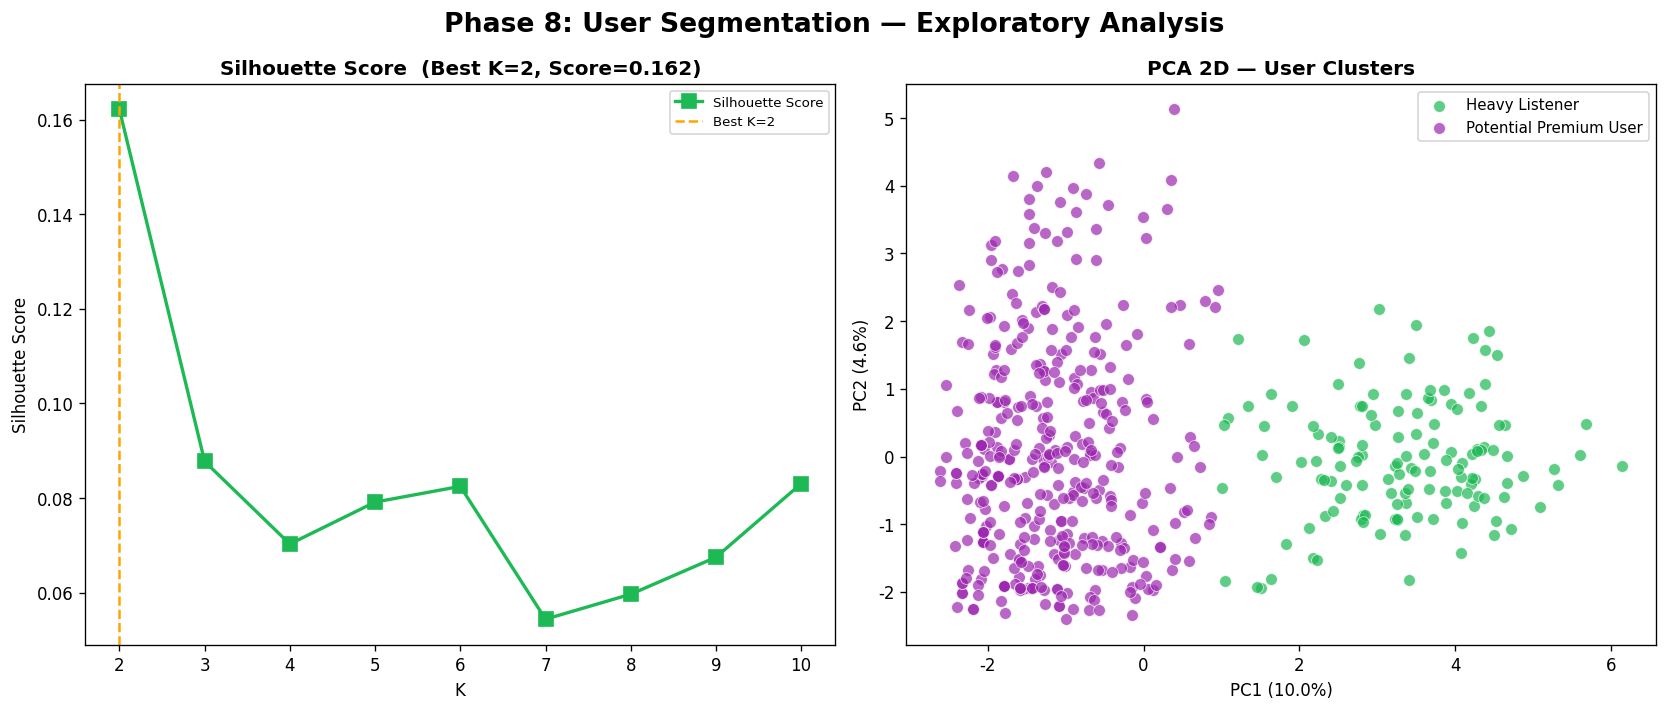

In [44]:
# --- 圖表 ---
colors_clus = ['#1DB954', '#9C27B0', '#FF6B35', '#2196F3',
               '#FFE66D', '#E63946'][:best_k]
persona_labels = [persona_map.get(i, f'Cluster {i}') for i in range(best_k)]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 8: User Segmentation — Exploratory Analysis', fontsize=16, fontweight='bold')
 
axes[0].plot(list(K_range), sil_scores, marker='s', color=SPOTIFY_GREEN, lw=2, markersize=8, label='Silhouette Score')
axes[0].axvline(best_k, color='orange', linestyle='--', label=f'Best K={best_k}')
axes[0].set_title(f'Silhouette Score  (Best K={best_k}, Score={sil_final:.3f})', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette Score')
axes[0].legend(loc='upper right', fontsize=8)
 
for i in range(best_k):
    mask = labels == i
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colors_clus[i], label=persona_labels[i],
                    alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
axes[1].set_title('PCA 2D — User Clusters', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.show()

### Cluster Persona<br>
> Cluster 0:<br>
Heavy Listener<br>
使用年資長、夜間高頻使用、推薦滿意度高，是黏著度最強的核心用戶；但付費意願尚未轉化（89% Free）<br>

> Cluster 1:<br>
Potential Premium User<br>
使用年資短但Free比例明顯較低（61%），以Podcast為主且推薦評分偏低，表示對現有體驗有更高期待，是最可能被推動升級的族群

### 商業洞察 Business Insights
Insight 1｜Premium轉換率在使用6個月至2年間達到最高水準<br>
Premium占比僅18.5%。Cohort Analysis顯示轉換率並非隨使用年資線性遞增：Less than 6 months（7.7%）→ 6 months to 1 year（22.7%）→ 1-2 years（22.0%）→ More than 2 years（18.3%）。Cramér's V=0.136（Weak），統計上顯著（p=0.0224）。在本樣本中，Premium轉換率於使用6個月至2年間達到最高水準，超過2年後略為下降，顯示現有付費機制對長期Free用戶的持續吸引力有限。

Insight 2｜推薦滿意度與付費意願並非單純正向關係<br>
t-test顯示Free用戶推薦評分（3.58）顯著高於Premium用戶（3.15，p=0.0001）。Phase 7 Association Analysis顯示低推薦評分用戶（1-2分）反而展現較高升級意願（44.3%），高於3-4分用戶（28.7%）。顯示推薦滿意度與付費意願並非單純正向關係，可能代表部分使用者希望透過Premium獲得更好的體驗，但本資料無法直接驗證其動機。不能假設推薦做得越好就越能帶動付費轉換。

Insight 3｜Podcast相關特徵是Premium轉換模型中最重要的一組特徵群<br>
Phase 6 SHAP Top Features整理為三類：<br>

>>⚪Device Preference：Smartphone使用是單一最強的SHAP特徵<br>
>>⚪Podcast Engagement：Podcast收聽頻率、Podcast Variety Satisfaction、偏好較長Podcast時長，三者合計為模型中影響力最高的特徵群<br>
>>⚪Music Preference：Sadness or Melancholy情緒與Rap音樂類型<br>

ROC-AUC（Random Forest）=0.6448，模型具有限度辨識能力，主要用途為探索影響Premium轉換的重要因子，而非建立精確預測系統。模型限制：資料來源為問卷，缺乏實際收聽紀錄、播放次數、付費歷史與活躍度指標。<br>

Insight 4｜Sadness or Melancholy族群展現最高Premium升級意願<br>
Phase 7 Association Analysis顯示，Sadness or Melancholy情緒用戶的Premium升級意願高達52.1%，遠高於其他情緒群組（28-38%）。顯示情緒相關內容偏好可能與付費意願存在關聯，值得作為後續精準行銷研究方向，但本資料無法驗證其背後動機。<br>

Insight 5｜多裝置使用與Premium訂閱存在關聯，但不代表其為主要轉換驅動因素<br>
Device × Premium分析：Single Device（15.6%）→ 2 Devices（27.6%）→ 3+ Devices（32.1%），多裝置使用者擁有較高Premium比例。但在Free用戶群體中，多裝置使用者並未展現出更高升級意願（3+ Devices Free用戶升級意願21.1%，低於Single Device的27.5%）。顯示多裝置使用與Premium訂閱存在關聯，但不一定代表其為主要轉換驅動因素。<br>

Insight 6｜推薦滿意度由聆聽情境與行為決定，與人口屬性幾乎無關<br>
Phase 5 Random Forest Regressor R²=0.2973，約解釋30%的推薦評分變異，在問卷資料環境下屬合理水準，分析重點應放在Feature Importance而非預測能力本身。Feature Importance前三名為music_lis_frequency（0.22）、music_expl_method（0.20）、music_Influencial_mood（0.12）；Age（0.028）與Gender（0.040）排名最低。推薦演算法的優化方向應針對使用情境與探索行為分層，行為變數的解釋力遠高於人口統計屬性。<br>

Insight 7｜Podcast相關指標具有較高轉換重要性，但使用率與滿意度均偏低<br>
63.7%用戶「很少」或「從不」聽Podcast，Podcast Variety Satisfaction滿意比例僅40.4%。Podcast相關特徵在Phase 6轉換模型中具有較高重要性，但目前Podcast使用比例與滿意度均偏低。顯示Podcast可能是值得進一步探索的成長方向，但需更多實際行為數據驗證其轉換效益。<br>

### 商業建議 Business Recommendations<br>
Recommendation 1｜在用戶使用第4-6個月時主動觸發升級<br>
依據Insight 1，Premium轉換率在使用6個月至2年間最高，超過2年後略降。建議在用戶達到使用第4-5個月時推送14天免費Premium試用或首月折扣，在轉換意願相對較高的時間點建立付費習慣。同時針對使用超過1年的長期Free用戶，設計老用戶專屬升級誘因，避免付費動力持續下降。<br>

Recommendation 2｜以Podcast體驗作為Premium核心差異化訴求<br>
依據Insight 3和7，Podcast相關特徵群在Premium轉換模型中重要性最高，且現有Podcast使用率與滿意度均偏低。建議Premium行銷材料主打Podcast離線下載、個人化Podcast推薦、更完整的Podcast內容庫，而非僅強調音樂功能。同時評估提升Podcast內容多樣性與探索機制，以改善目前40.4%的滿意度水準。<br>

Recommendation 3｜針對Premium用戶採用分層推薦策略<br>
依據Insight 2，Premium用戶推薦評分（3.15）顯著低於Free用戶（3.58），顯示付費後期待提升、對推薦品質更敏感。建議針對Premium用戶提供可調整推薦偏好的設定選項，或增加人工策展內容的比例，以降低付費用戶因推薦不符期待而流失的風險。<br>

Recommendation 4｜將情緒型內容偏好作為行銷研究方向<br>
依據Insight 4，Sadness or Melancholy族群升級意願（52.1%）顯著高於其他群組。建議將情緒相關內容偏好納入行銷受眾分析，測試情境型文案（例如主打音樂陪伴、情緒支持等訴求）是否能提升此族群的實際轉換率，並透過A/B Test驗證效果。<br>

Recommendation 5｜針對多裝置Free用戶展示Premium功能差異<br>
依據Insight 5，多裝置使用者Premium比例較高，但多裝置Free用戶升級意願並不突出。建議針對使用2+裝置的Free用戶，在產品內展示跨裝置無縫切換、跨裝置離線下載等Premium限定功能，讓使用情境中的體驗差異成為升級的參考因素，而非單純依賴行銷文案觸達。<br>

Recommendation 6｜行銷資源依行為訊號分層，而非人口統計<br>
依據Insight 6，Age與Gender的Feature Importance最低，以人口統計作為Premium推廣主要分群依據效益有限。建議將行銷資源優先投入行為訊號分層：<br>

| 行為訊號 | 建議策略方向 |
|---|---|
| 使用 4–6 個月、有 Podcast 使用紀錄 | 優先升級觸達對象 |
| 多裝置使用、Free 用戶 | 展示跨裝置 Premium 功能差異 |
| 情緒型內容偏好（Sadness / Melancholy） | 情境型行銷文案測試 |
| 使用 2 年以上、Free 用戶 | 老用戶專屬方案 |